# Credit Risk — Exploratory Data Analysis
## *Give Me Some Credit* · Kaggle Competition Dataset

---

### Background

**Credit risk** is the probability that a borrower will fail to meet their contractual debt obligations.  
It sits at the centre of modern banking: every loan approval, credit-card limit, and mortgage rate is ultimately backed by an estimate of this probability — the **Probability of Default (PD)**.

Banks and credit providers rely on statistical models that translate borrower characteristics into a PD score.  
Poor risk assessment leads to either:
- **Under-lending** — declining creditworthy applicants (opportunity cost), or  
- **Over-lending** — approving high-risk borrowers (write-off losses, regulatory capital requirements).

The Basel II/III accords require institutions to estimate PD internally; getting it right has direct regulatory and commercial consequences.

### Dataset

The dataset comes from the Kaggle competition *"Give Me Some Credit"* (2011).  
It contains anonymised financial and delinquency data for **150,000 borrowers**.  
The **target variable** (`SeriousDlqin2yrs`) equals **1** if the borrower experienced 90+ days past due delinquency within 2 years, and **0** otherwise.  
This notebook focuses entirely on **understanding the data** before any modelling takes place.

### Notebook Structure
1. Setup & Imports  
2. Data Loading & Data Dictionary  
3. Data Cleaning  
4. Missingness Analysis  
5. Univariate Analysis  
6. Target Variable & Class Imbalance  
7. Bivariate Analysis  
8. Correlation Analysis  
9. Mutual Information  
10. Key Findings Summary

---
## 1 · Setup & Imports

In [45]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

from sklearn.feature_selection import mutual_info_classif
from scipy import stats

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
np.random.seed(SEED)

# ── colour palette ───────────────────────────────────────────────────────────
GOOD_CLR  = '#4C9BE8'   # non-default (0)
BAD_CLR   = '#E8604C'   # default     (1)
TARGET_PALETTE = {0: GOOD_CLR, 1: BAD_CLR}

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2 · Data Loading & Data Dictionary

In [46]:
# ── load raw data ────────────────────────────────────────────────────────────
raw = pd.read_csv('../Data/cs-training.csv', index_col=0)

# ── friendly column names (mirrors the R analysis) ──────────────────────────
RENAME = {
    'SeriousDlqin2yrs':                    'defaulted',
    'RevolvingUtilizationOfUnsecuredLines': 'unsecured_credit',
    'age':                                 'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'delinq_30_59',
    'DebtRatio':                           'debt_ratio',
    'MonthlyIncome':                       'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':      'open_credit',
    'NumberOfTimes90DaysLate':             'delinq_90',
    'NumberRealEstateLoansOrLines':         'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'delinq_60_89',
    'NumberOfDependents':                  'dependents',
}
raw.rename(columns=RENAME, inplace=True)

print(f'Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}')
raw.head()

Rows: 150,000   Columns: 11


,defaulted,unsecured_credit,age,delinq_30_59,debt_ratio,monthly_income,open_credit,delinq_90,real_estate_loans,delinq_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [47]:
# ── data dictionary ──────────────────────────────────────────────────────────
dict_raw = pd.read_excel('../Data/Data Dictionary.xls', header=0)
dict_raw.columns = ['Variable', 'Description', 'Type']
dict_raw = dict_raw.iloc[1:].reset_index(drop=True)   # drop the repeated header row

# map to friendly names
dict_raw['Short Name'] = dict_raw['Variable'].map(RENAME).fillna(dict_raw['Variable'])
dict_raw[['Short Name', 'Variable', 'Description', 'Type']].style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,Short Name,Variable,Description,Type
0,defaulted,SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
1,unsecured_credit,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
2,age,age,Age of borrower in years,integer
3,delinq_30_59,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
4,debt_ratio,DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
5,monthly_income,MonthlyIncome,Monthly income,real
6,open_credit,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
7,delinq_90,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
8,real_estate_loans,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
9,delinq_60_89,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


## 3 · Data Cleaning

Before any analysis we remove known data quality issues:

| Issue | Filter Applied | Rationale |
|---|---|---|
| `age == 0` | `age > 0` | A borrower aged 0 is impossible |
| `delinq_30_59 ∈ {96, 98}` | `delinq_90 < 96` | These sentinel values appear simultaneously across all delinquency columns — they are codes, not real counts |

> **Note:** `unsecured_credit` can exceed 1.0 (interest and fees push balances above the credit limit) and `debt_ratio` can exceed 1.0 (debt payments larger than gross income). Both are retained as valid, informative signals.

In [48]:
df = raw.copy()

n_before = len(df)
df = df[df['age'] > 0]
df = df[df['delinq_90'] < 96]
n_after = len(df)

print(f'Rows removed : {n_before - n_after:,}  ({(n_before - n_after)/n_before:.1%})')
print(f'Rows retained: {n_after:,}')
df.describe().T.style.format('{:.3f}').background_gradient(cmap='Blues', axis=1)

Rows removed : 270  (0.2%)
Rows retained: 149,730


,count,mean,std,min,25%,50%,75%,max
defaulted,149730.000,0.066,0.248,0.000,0.000,0.000,0.000,1.000
unsecured_credit,149730.000,6.058,249.980,0.000,0.030,0.153,0.556,50708.000
age,149730.000,52.328,14.754,21.000,41.000,52.000,63.000,109.000
delinq_30_59,149730.000,0.246,0.698,0.000,0.000,0.000,0.000,13.000
debt_ratio,149730.000,353.631,2039.601,0.000,0.176,0.367,0.870,329664.000
monthly_income,120120.000,6675.295,14392.547,0.000,3400.000,5400.000,8250.000,3008750.000
open_credit,149730.000,8.468,5.138,0.000,5.000,8.000,11.000,58.000
delinq_90,149730.000,0.090,0.486,0.000,0.000,0.000,0.000,17.000
real_estate_loans,149730.000,1.020,1.130,0.000,0.000,1.000,2.000,54.000
delinq_60_89,149730.000,0.065,0.330,0.000,0.000,0.000,0.000,11.000


---
## 4 · Missingness Analysis

### Theory

Missing data is rarely random. Understanding **why** data is missing is as important as knowing **how much** is missing.  
Rubin (1976) classifies missing data into three mechanisms:

| Mechanism | Acronym | Meaning |
|---|---|---|
| Missing Completely At Random | **MCAR** | Missingness is unrelated to any data, observed or unobserved. Safe to drop rows. |
| Missing At Random | **MAR** | Missingness depends only on *observed* variables. Imputation conditioned on observed covariates is valid. |
| Missing Not At Random | **MNAR** | Missingness depends on the *unobserved* value itself (e.g. high earners less likely to report income). Most dangerous — imputation can bias results. |

**In credit scoring**, `MonthlyIncome` is often MNAR: high-income individuals may omit income fields on applications. The appropriate strategy depends on the mechanism and the predictive importance of the variable.

In [49]:
# ── missing value summary table ──────────────────────────────────────────────
miss = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     df.isnull().mean() * 100,
    'Dtype':         df.dtypes,
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

miss.style \
    .format({'Missing Count': '{:,.0f}', 'Missing %': '{:.2f}%'}) \
    .background_gradient(subset=['Missing %'], cmap='Reds')

,Missing Count,Missing %,Dtype
monthly_income,"29,610",19.78%,float64
dependents,"3,893",2.60%,float64


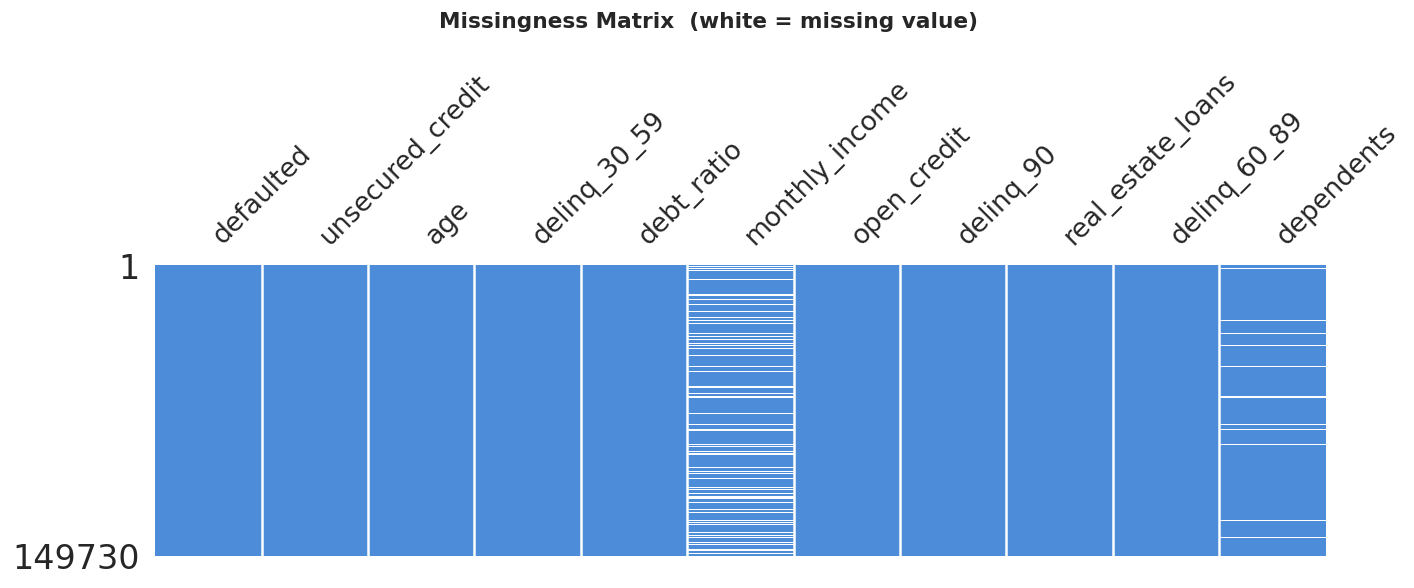

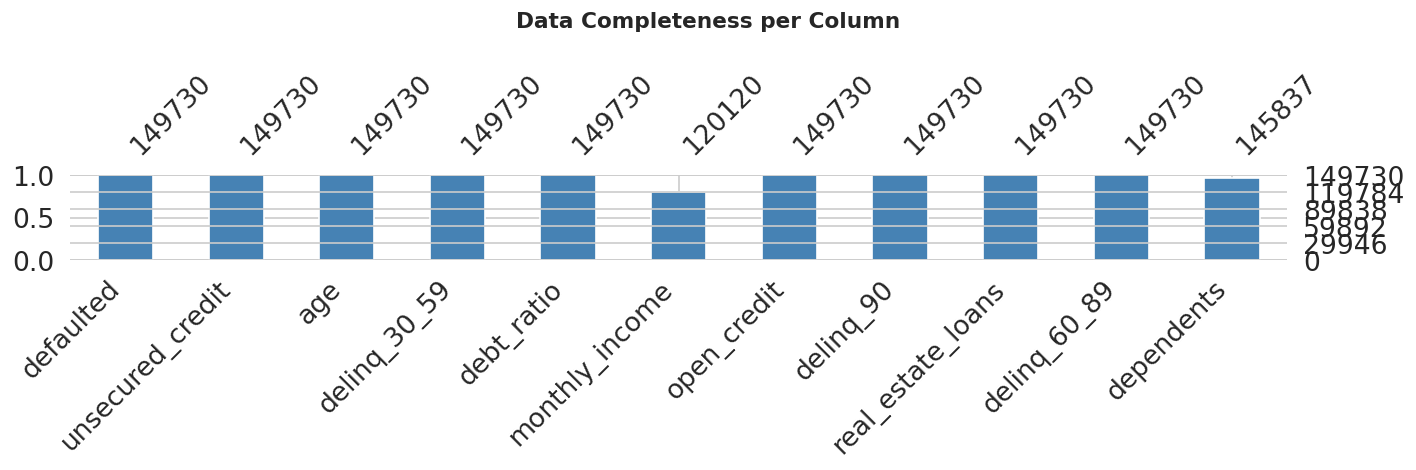

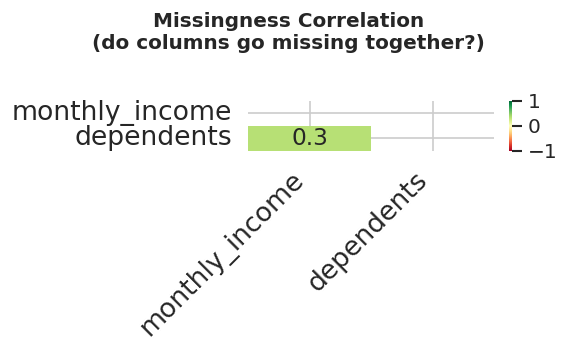

In [50]:
# ── 1. Missingness matrix — row-level patterns (white stripe = missing) ──────
msno.matrix(df, sparkline=False, color=(0.3, 0.55, 0.85), figsize=(12, 5))
plt.gcf().suptitle('Missingness Matrix  (white = missing value)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Bar chart — completeness per column ────────────────────────────────────
msno.bar(df, color='steelblue', figsize=(12, 4))
plt.gcf().suptitle('Data Completeness per Column', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Heatmap — do columns go missing together? ─────────────────────────────
# Only columns with any missingness appear; here: monthly_income & dependents.
# A positive correlation (~0.3) means they tend to be missing on the same rows.
msno.heatmap(df, cmap='RdYlGn', figsize=(5, 3))
plt.gcf().suptitle('Missingness Correlation\n(do columns go missing together?)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


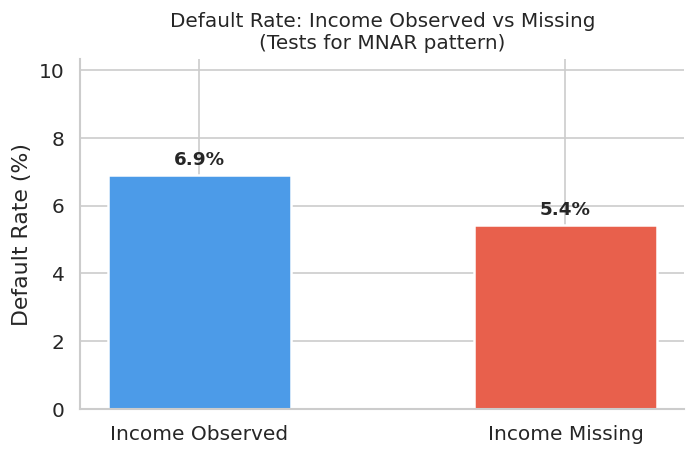

Chi-square test — χ²=82.32,  p=0.0000
→ Missingness in monthly_income is SIGNIFICANTLY associated with default status.


In [51]:
# ── is missingness in monthly_income related to default status? (MNAR test) ──
df['income_missing'] = df['monthly_income'].isnull().astype(int)

miss_default_rate = df.groupby('income_missing')['defaulted'].mean().rename({0: 'Income Observed', 1: 'Income Missing'})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(miss_default_rate.index, miss_default_rate.values * 100,
              color=[GOOD_CLR, BAD_CLR], edgecolor='white', linewidth=1.5, width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate: Income Observed vs Missing\n(Tests for MNAR pattern)', fontsize=12)
ax.set_ylim(0, miss_default_rate.max() * 150)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Income Observed', 'Income Missing'])
plt.tight_layout()
plt.show()

# chi-square test
ct = pd.crosstab(df['income_missing'], df['defaulted'])
chi2, p_val, _, _ = stats.chi2_contingency(ct)
print(f'Chi-square test — χ²={chi2:.2f},  p={p_val:.4f}')
print('→ Missingness in monthly_income is', 'SIGNIFICANTLY' if p_val < 0.05 else 'NOT significantly', 'associated with default status.')

df.drop(columns='income_missing', inplace=True)

### Imputation Strategy

Given the MAR/MNAR nature of the missing fields:

- **`monthly_income`** (19.8% missing): Impute with the **median** (robust to the right-skewed income distribution and high-earner outliers). A more principled approach for modelling would be multiple imputation or a regression-based imputer.
- **`dependents`** (2.6% missing): Impute with **0** — conservative assumption that unreported dependents are absent; confirmed to have low predictive importance.

In [52]:
# ── Missing indicators (before imputation) ───────────────────────────────────
# Binary flags preserve the information that a value was absent.
# These can be used as features in downstream models.
# Use raw to ensure indicators are correct regardless of re-execution order
df['monthly_income_missing'] = raw.loc[df.index, 'monthly_income'].isna().astype(int)
df['dependents_missing']     = raw.loc[df.index, 'dependents'].isna().astype(int)

print('Missing indicator counts:')
print(df[['monthly_income_missing', 'dependents_missing']].sum().to_string())

# ── Imputation ────────────────────────────────────────────────────────────────
median_income = df['monthly_income'].median()
df['monthly_income'] = df['monthly_income'].fillna(median_income)
df['dependents']     = df['dependents'].fillna(0)

print(f'Imputed monthly_income NAs with median: ${median_income:,.0f}')
print(f'Imputed dependents NAs with 0')
print(f'Remaining missing values: {df.isnull().sum().sum()}')


Missing indicator counts:
monthly_income_missing    29610
dependents_missing         3893
Imputed monthly_income NAs with median: $5,400
Imputed dependents NAs with 0
Remaining missing values: 0


---
## 5 · Univariate Analysis

Univariate analysis examines each feature in isolation.  
Key questions:
- What is the **shape** of each distribution (normal, skewed, bimodal)?
- Are there **outliers** or impossible values remaining?
- What is the **scale** and **spread** of each variable?

For modelling, highly skewed variables often benefit from log-transformation. For EDA purposes we report them as-is and note the skew.

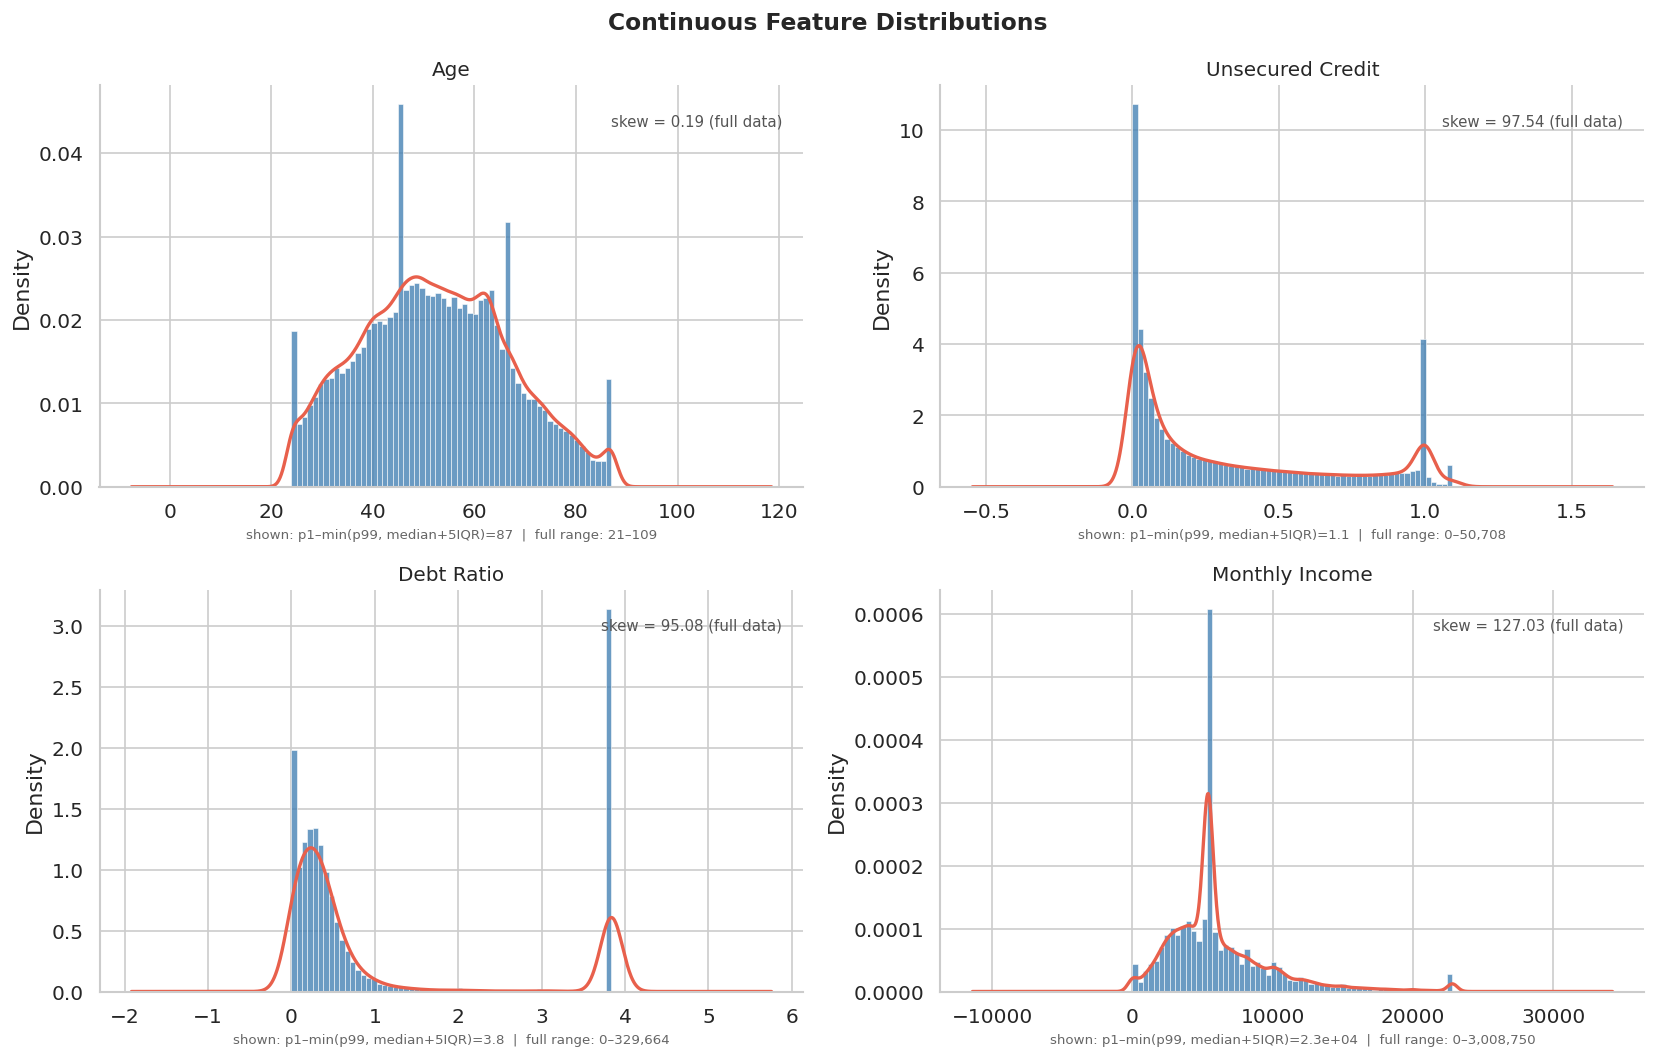

In [53]:
# continuous features
# x-axis clipped to min(p99, median + 5*IQR) so heavy-tailed features
# (e.g. debt_ratio, monthly_income) show their actual bulk distribution.
continuous = ["age", "unsecured_credit", "debt_ratio", "monthly_income"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(continuous):
    ax = axes[i]
    data = df[col].dropna()
    skew = data.skew()

    p01  = data.quantile(0.01)
    p25, p50, p75 = data.quantile(0.25), data.quantile(0.50), data.quantile(0.75)
    p99  = data.quantile(0.99)
    iqr_fence = p50 + 5 * (p75 - p25)
    hi = min(p99, iqr_fence) if iqr_fence > p50 else p99

    clipped = data.clip(p01, hi)

    ax.hist(clipped, bins=60, color="steelblue", edgecolor="white",
            linewidth=0.4, density=True, alpha=0.8)
    clipped.plot.kde(ax=ax, color="#E8604C", linewidth=2)

    ax.set_title(col.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel(
        "shown: p1–min(p99, median+5IQR)={:.2g}  |  full range: {:.2g}–{:,.0f}".format(hi, data.min(), data.max()),
        fontsize=8, color="#666"
    )
    ax.text(0.97, 0.93, "skew = {:.2f} (full data)".format(skew),
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="#555")

plt.suptitle("Continuous Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


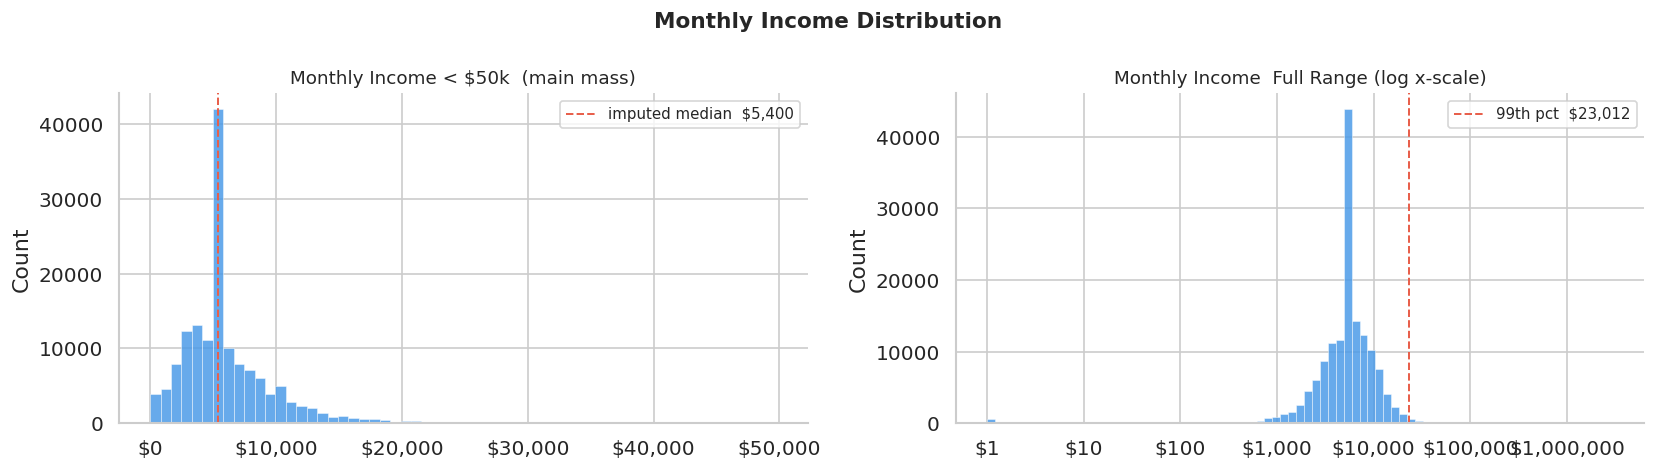

In [54]:
# monthly income: main mass + log-scale full range
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: main mass < 50k  (linear bins)
subset = df.loc[df["monthly_income"] < 50_000, "monthly_income"]
axes[0].hist(subset, bins=60, color="#4C9BE8", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(x)))
axes[0].set_title("Monthly Income < $50k  (main mass)", fontsize=11)
axes[0].set_ylabel("Count")
median_line = df["monthly_income"].median()
axes[0].axvline(median_line, color="#E8604C", linestyle="--", linewidth=1.2,
                label="imputed median  ${:,.0f}".format(int(median_line)))
axes[0].legend(fontsize=9)

# Right: full range with log-spaced bins so each decade gets equal resolution
pos = df.loc[df["monthly_income"] > 0, "monthly_income"]
log_bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 80)
axes[1].hist(pos, bins=log_bins, color="#4C9BE8", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
axes[1].set_title("Monthly Income  Full Range (log x-scale)", fontsize=11)
axes[1].set_ylabel("Count")
p99 = df["monthly_income"].quantile(0.99)
axes[1].axvline(p99, color="#E8604C", linestyle="--", linewidth=1.2,
                label="99th pct  ${:,.0f}".format(int(p99)))
axes[1].legend(fontsize=9)

plt.suptitle("Monthly Income Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


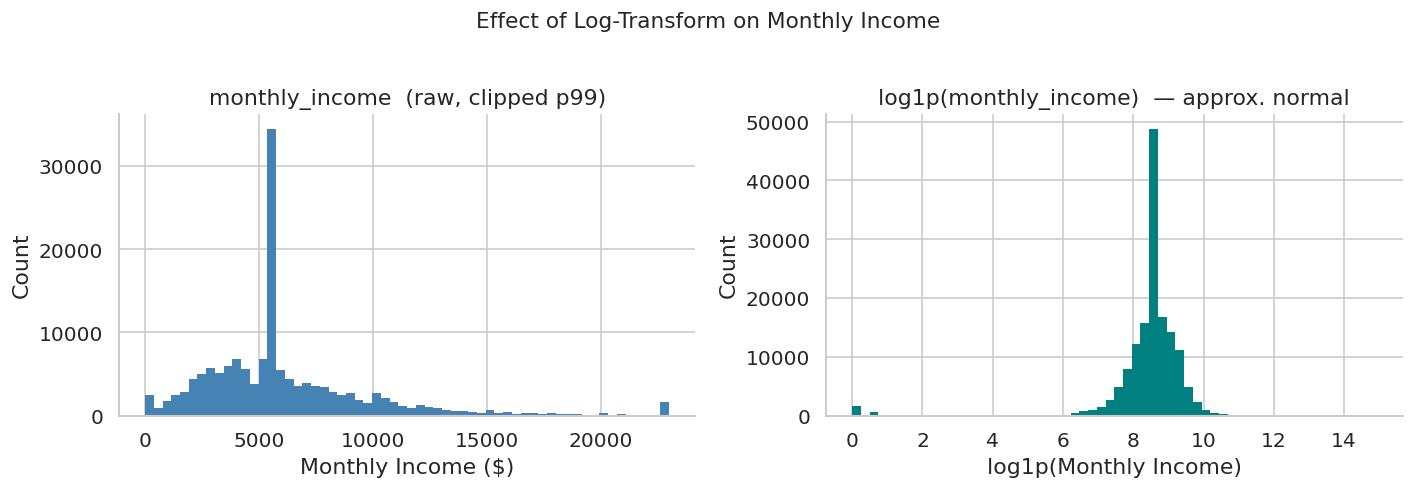

Raw skewness   : 127.03
Log1p skewness : -4.94


In [55]:
# ── Log-transform of monthly_income ───────────────────────────────────────────
# Right-skew makes linear models assume a much wider income range than reality.
# log1p(x) = log(1+x) handles the small number of zero-income rows gracefully.

log_income = np.log1p(df['monthly_income'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['monthly_income'].clip(upper=df['monthly_income'].quantile(0.99)),
             bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('monthly_income  (raw, clipped p99)')
axes[0].set_xlabel('Monthly Income ($)')

axes[1].hist(log_income, bins=60, color='teal', edgecolor='none')
axes[1].set_title('log1p(monthly_income)  — approx. normal')
axes[1].set_xlabel('log1p(Monthly Income)')

for ax in axes:
    ax.set_ylabel('Count')

plt.suptitle('Effect of Log-Transform on Monthly Income', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Raw skewness   : {df['monthly_income'].skew():.2f}")
print(f"Log1p skewness : {log_income.skew():.2f}")

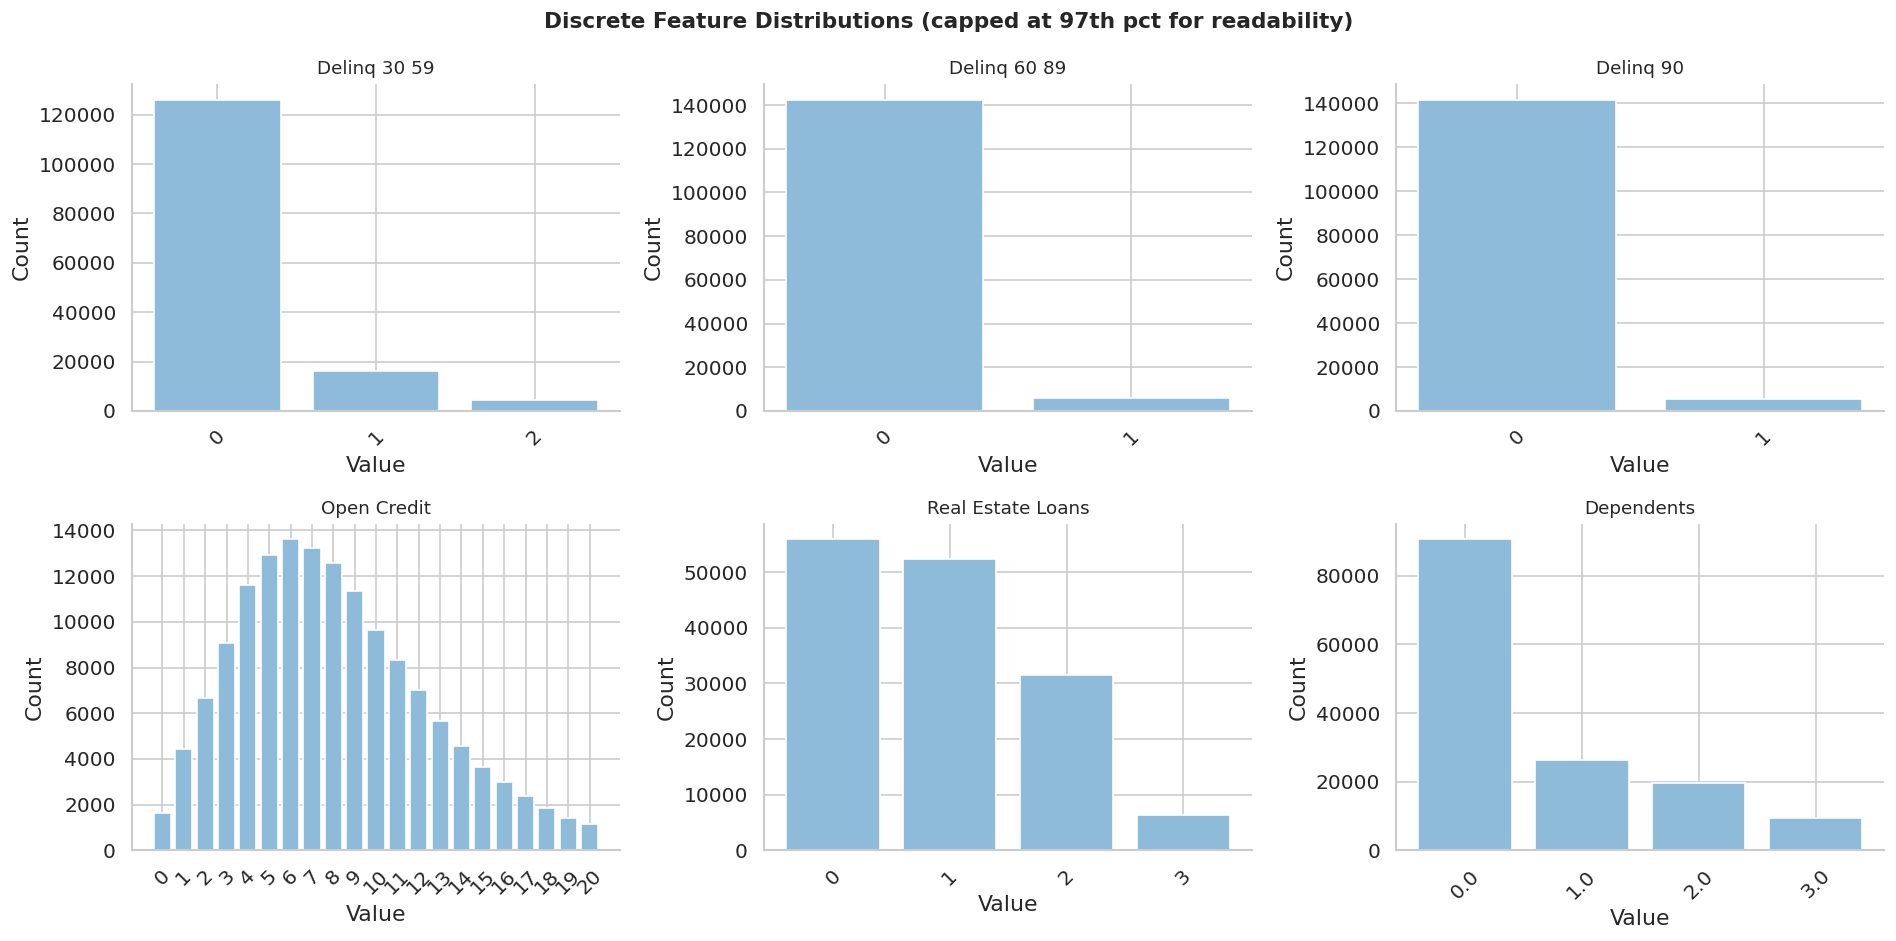

In [56]:
# ── discrete / count features ────────────────────────────────────────────────
discrete = ['delinq_30_59', 'delinq_60_89', 'delinq_90',
            'open_credit', 'real_estate_loans', 'dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(discrete):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    # cap at 95th percentile for readability
    cap = df[col].quantile(0.97)
    counts = counts[counts.index <= cap]
    ax.bar(counts.index.astype(str), counts.values, color='#8fbbda', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Discrete Feature Distributions (capped at 97th pct for readability)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

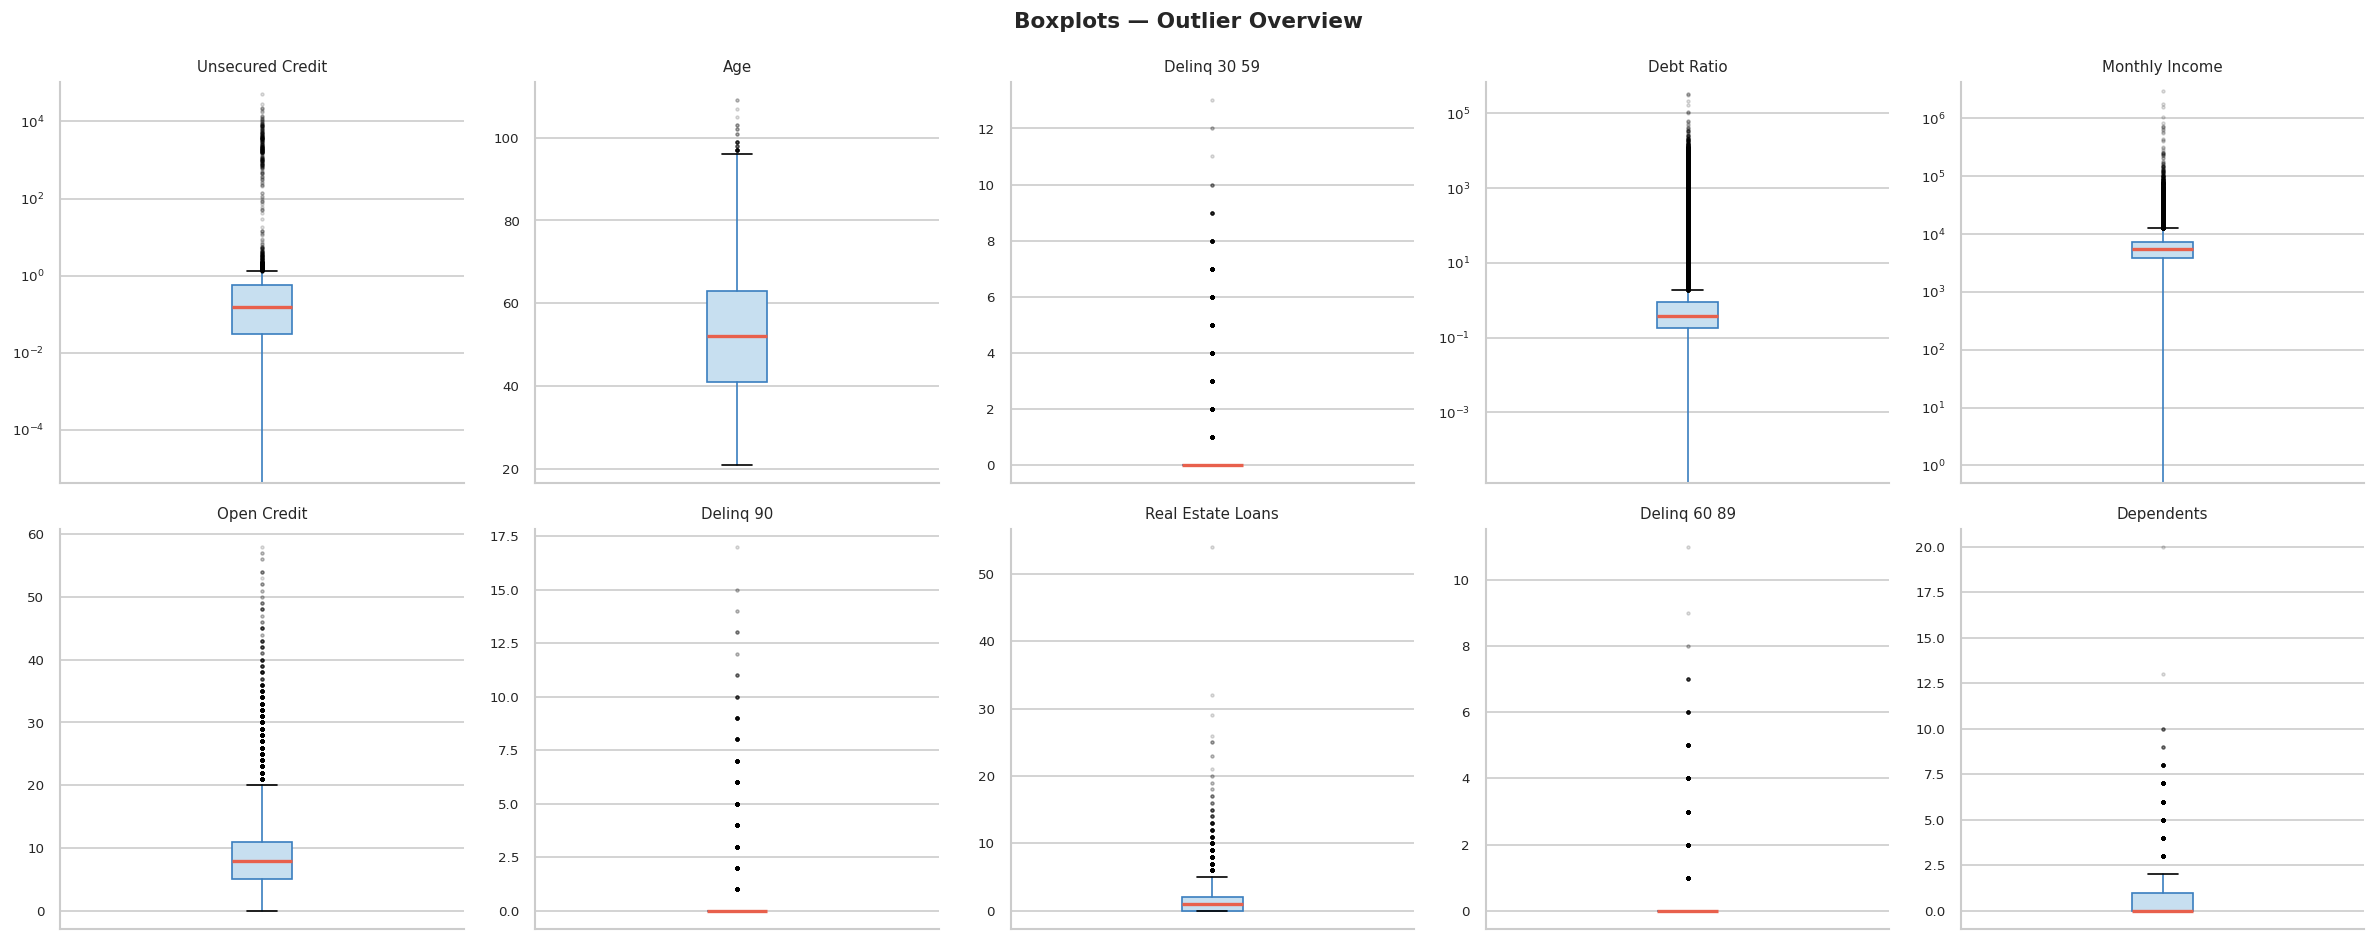

In [57]:
# Boxplots — log y-scale only for the three heavy-tailed continuous columns;
# count/discrete columns (delinq_*, open_credit, dependents) use linear scale.
LOG_SCALE_COLS = {"unsecured_credit", "debt_ratio", "monthly_income"}
num_cols = [c for c in df.columns
            if c not in ("defaulted", "monthly_income_missing", "dependents_missing")]

ncols = 5
nrows = (len(num_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#c7dff0", color="#3a7ebf"),
               medianprops=dict(color="#E8604C", linewidth=2),
               whiskerprops=dict(color="#3a7ebf"),
               flierprops=dict(marker=".", color="#E8604C", alpha=0.2, markersize=3))
    if col in LOG_SCALE_COLS:
        pos_min = data[data > 0].min() if (data > 0).any() else 1e-3
        ax.set_yscale("log")
        ax.set_ylim(bottom=pos_min * 0.5)
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — Outlier Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 6 · Target Variable & Class Imbalance

### Theory

**Class imbalance** is a fundamental challenge in credit risk modelling.  
Real-world default rates are typically between 2 – 10%, meaning the dataset is highly skewed towards non-defaults.

Naive classifiers that simply predict 0 for everyone would achieve ~93% accuracy but provide zero value.  
Addressing imbalance is critical for building useful models. Common strategies include:

| Technique | Idea |
|---|---|
| **Over-sampling** (e.g. SMOTE) | Synthetically generate minority class samples |
| **Under-sampling** | Reduce majority class samples |
| **Cost-sensitive learning** | Penalise misclassification of the minority class more heavily |
| **Threshold tuning** | Choose a decision threshold that balances precision/recall for business needs |

The appropriate strategy depends on the **cost asymmetry**: in lending, a missed default (false negative) is usually far more costly than a declined good customer (false positive).

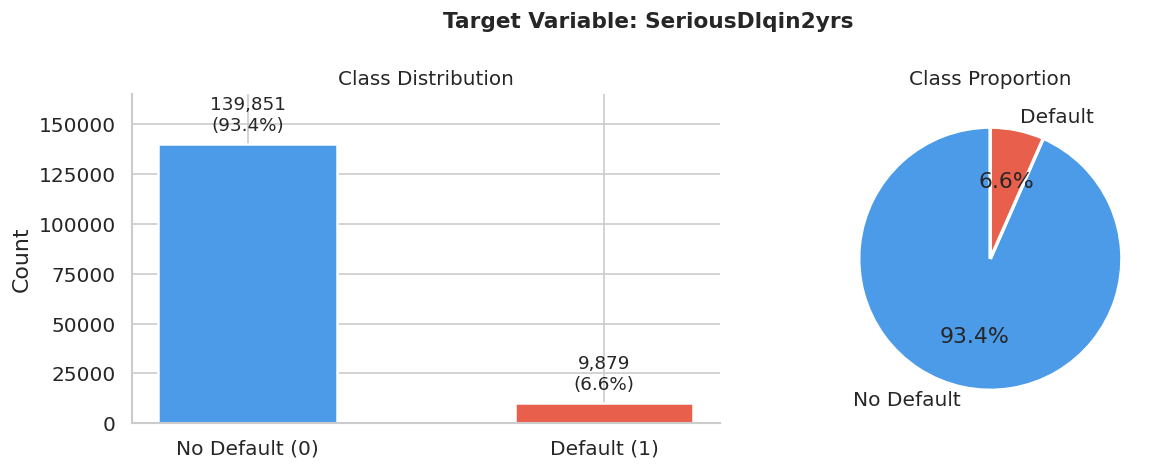

Imbalance ratio (non-default : default) = 14.2 : 1


In [58]:
target_counts = df['defaulted'].value_counts().sort_index()
target_pct    = (target_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# bar chart
bars = axes[0].bar(['No Default (0)', 'Default (1)'],
                   target_counts.values,
                   color=[GOOD_CLR, BAD_CLR], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].bar_label(bars,
                  labels=[f'{v:,}\n({p:.1f}%)' for v, p in zip(target_counts.values, target_pct.values)],
                  padding=6, fontsize=11)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, target_counts.max() * 1.18)

# pie chart
axes[1].pie(target_counts.values,
            labels=['No Default', 'Default'],
            colors=[GOOD_CLR, BAD_CLR],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=12)

plt.suptitle('Target Variable: SeriousDlqin2yrs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ir = target_counts[0] / target_counts[1]
print(f'Imbalance ratio (non-default : default) = {ir:.1f} : 1')

---
## 7 · Bivariate Analysis

Bivariate analysis examines the relationship between **each feature and the target**.  
This surfaces which variables are the most discriminating — i.e. which features shift meaningfully between the default and non-default groups.

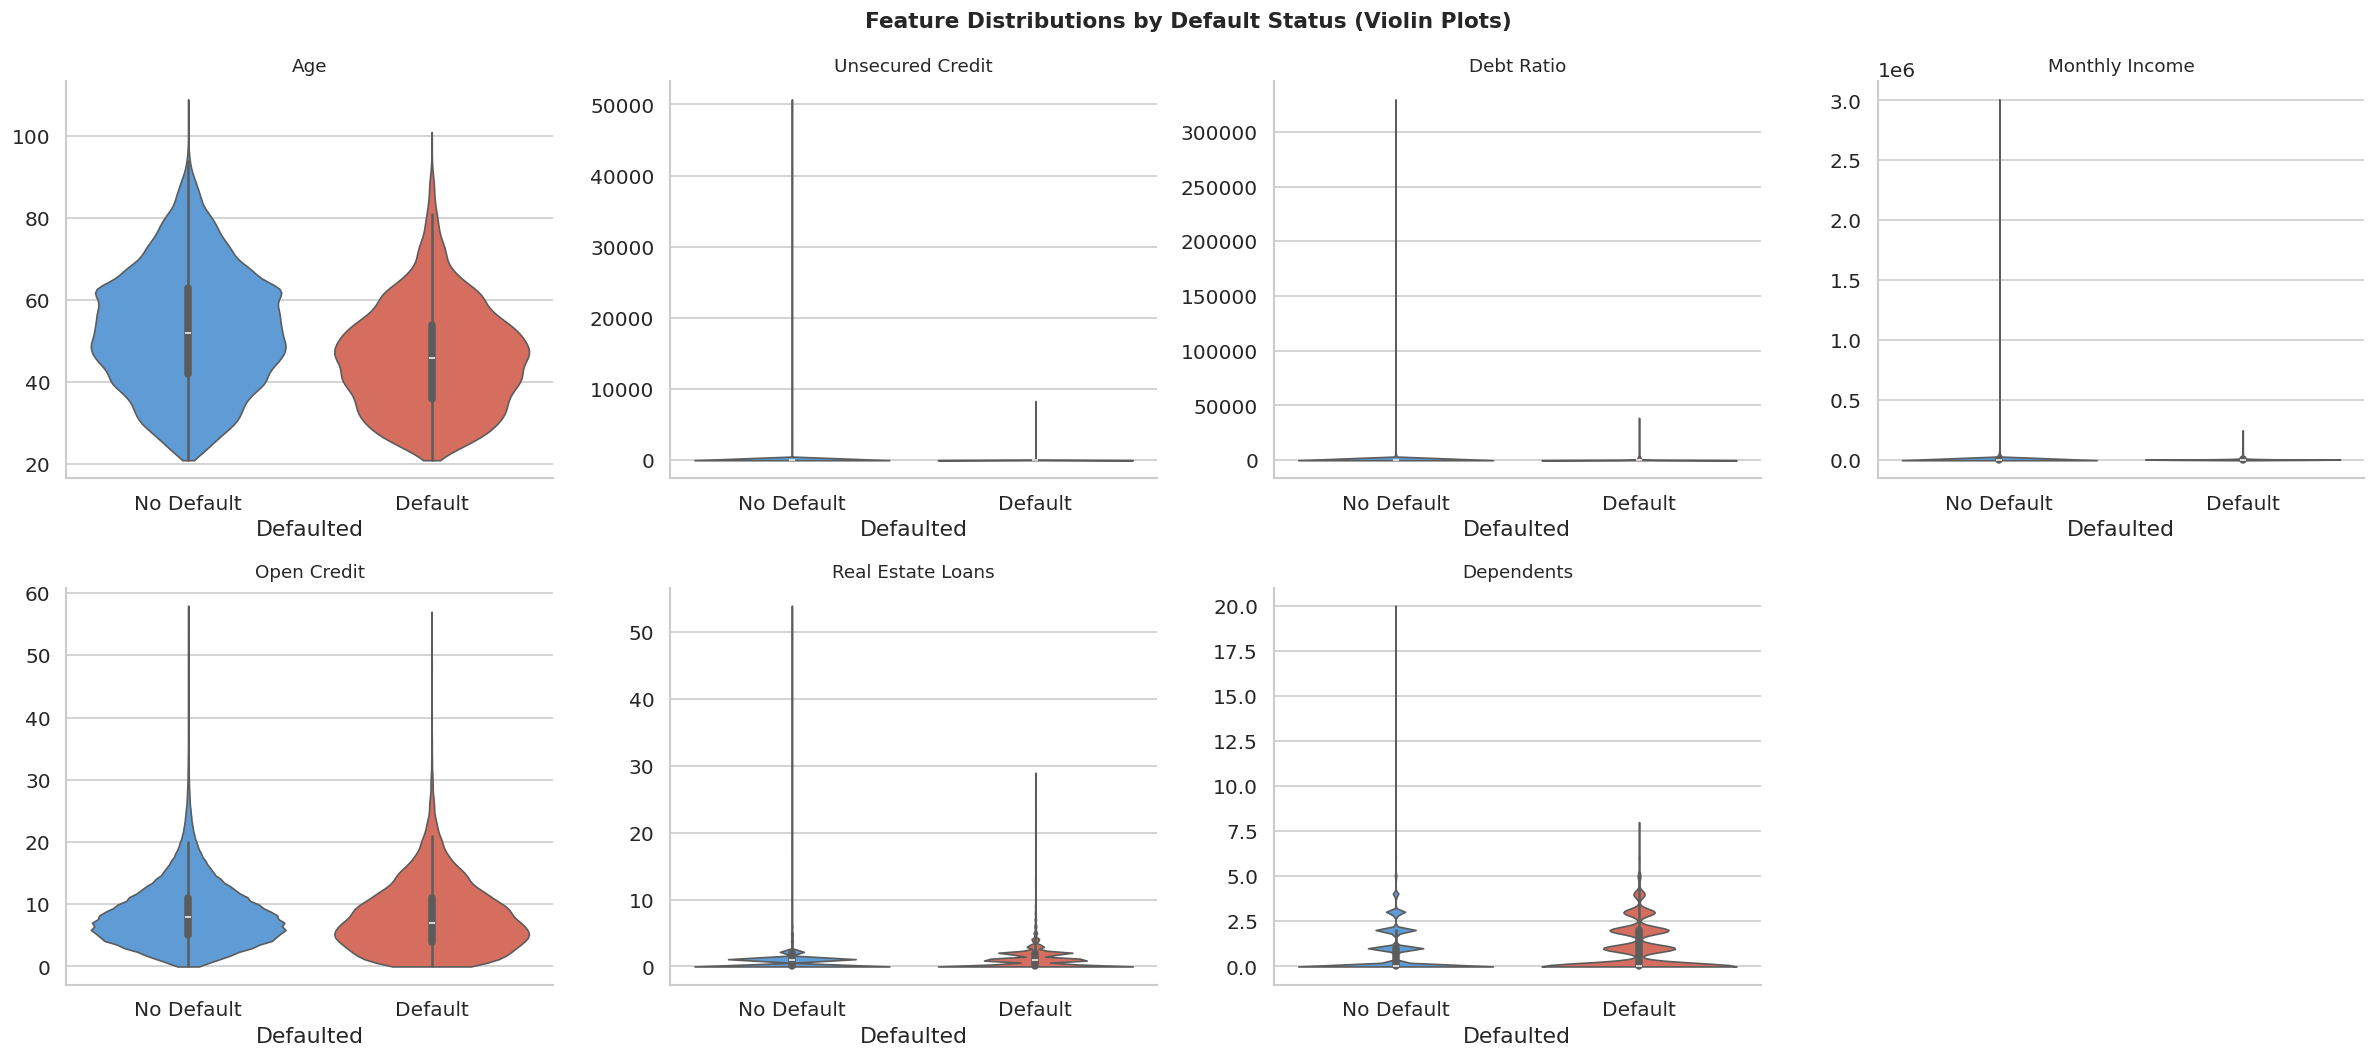

In [59]:
# ── violin + box overlaid per feature, split by target ───────────────────────
features = ['age', 'unsecured_credit', 'debt_ratio', 'monthly_income',
            'open_credit', 'real_estate_loans', 'dependents']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.violinplot(data=df, x='defaulted', y=col, ax=ax,
                   palette=[GOOD_CLR, BAD_CLR], inner='box', hue='defaulted', legend=False,
                   cut=0, linewidth=1)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Defaulted')
    ax.set_ylabel('')
    ax.set_xticklabels(['No Default', 'Default'])

axes[-1].axis('off')   # hide the spare subplot
plt.suptitle('Feature Distributions by Default Status (Violin Plots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

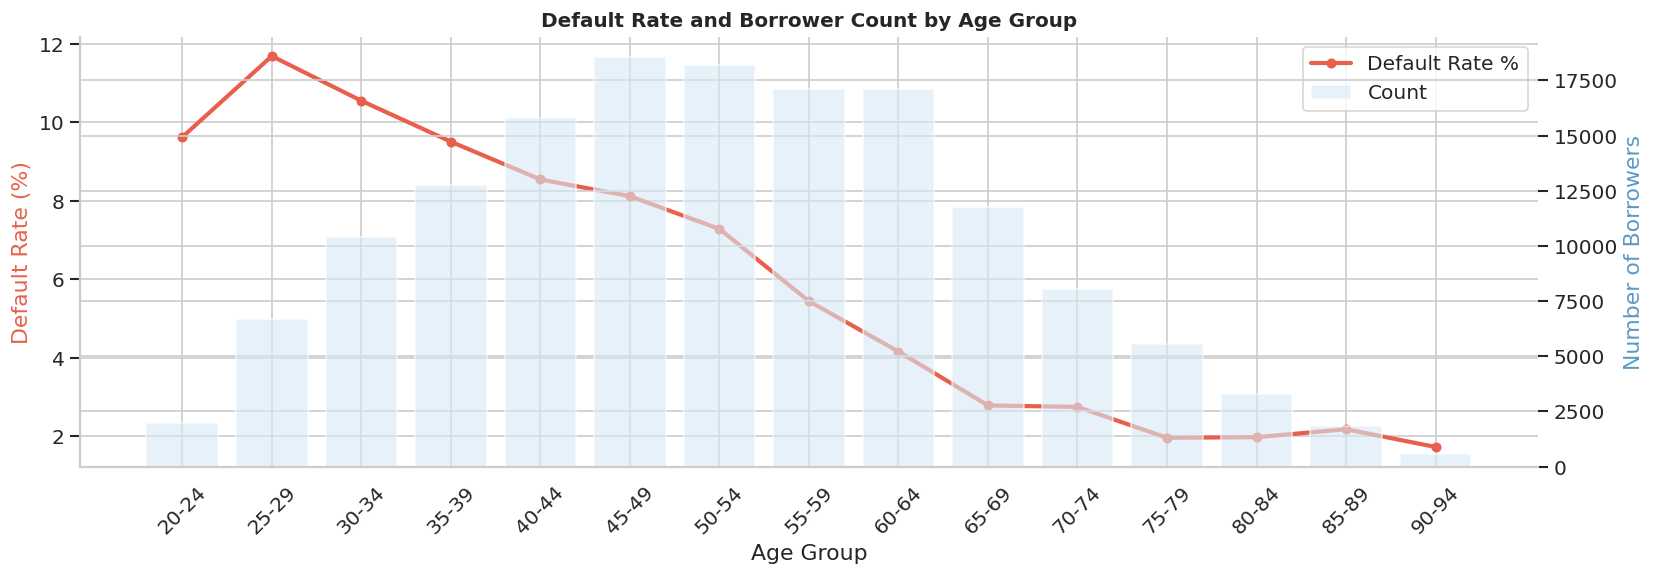

In [60]:
# ── default rate by age group ────────────────────────────────────────────────
df['age_group'] = pd.cut(df['age'], bins=range(20, 100, 5),
                          right=False,
                          labels=[f'{a}-{a+4}' for a in range(20, 95, 5)])

age_default = df.groupby('age_group', observed=True)['defaulted'].agg(['mean', 'count']).reset_index()
age_default['default_rate'] = age_default['mean'] * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax2.bar(age_default['age_group'].astype(str), age_default['count'],
        color='#d6e9f5', alpha=0.6, label='Count')
ax1.plot(age_default['age_group'].astype(str), age_default['default_rate'],
         color=BAD_CLR, marker='o', linewidth=2.5, markersize=5, label='Default Rate %', zorder=5)

ax1.set_ylabel('Default Rate (%)', color=BAD_CLR)
ax2.set_ylabel('Number of Borrowers', color='#5b9ac4')
ax1.set_xlabel('Age Group')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Default Rate and Borrower Count by Age Group', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

df.drop(columns='age_group', inplace=True)

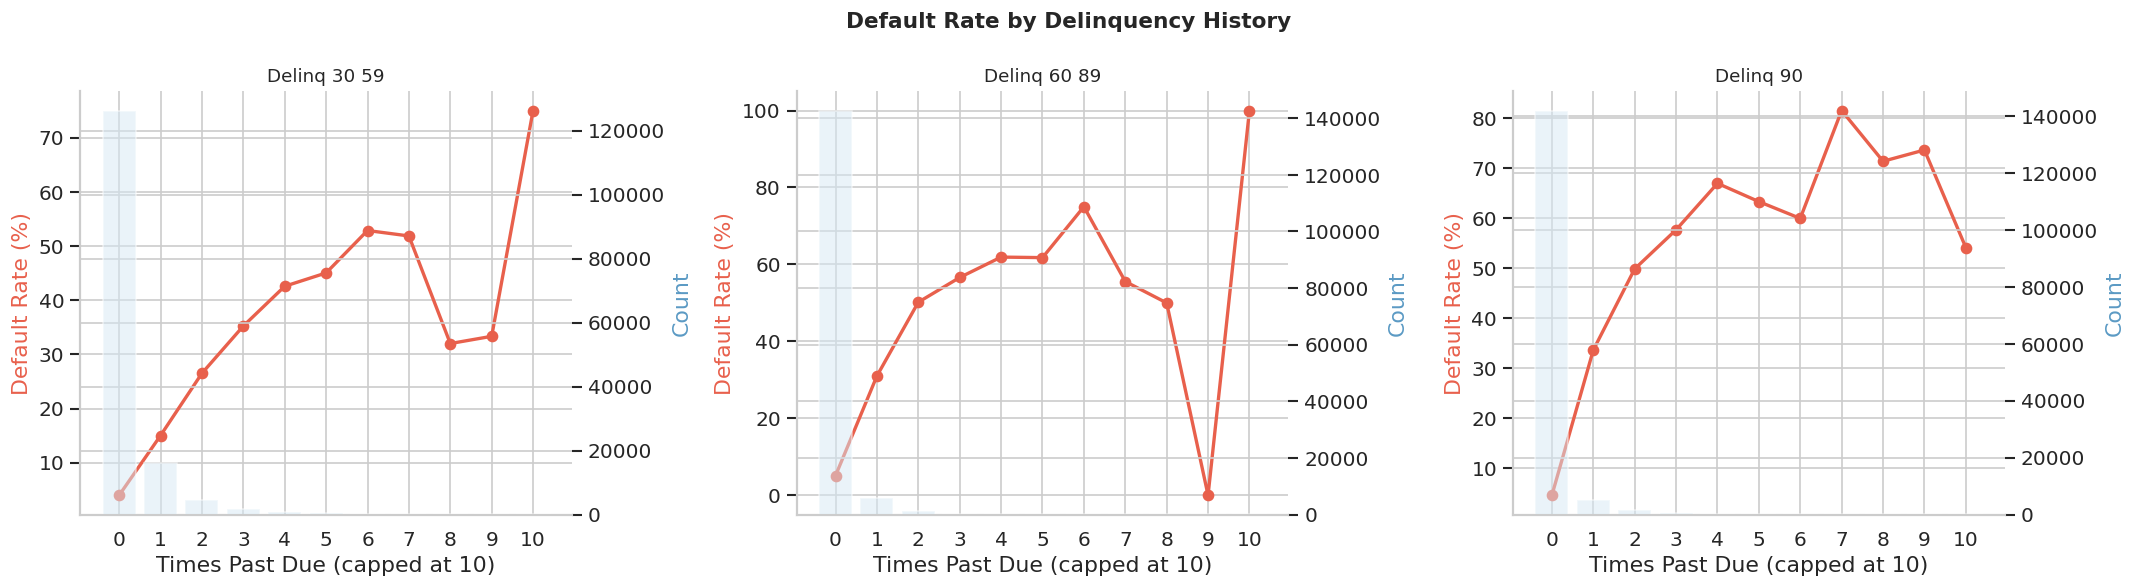

In [61]:
# ── default rate by delinquency variables ────────────────────────────────────
delinq_cols = ['delinq_30_59', 'delinq_60_89', 'delinq_90']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, delinq_cols):
    # cap at 10 for readability
    temp = df.copy()
    temp[col] = temp[col].clip(upper=10)
    rates = temp.groupby(col)['defaulted'].mean() * 100
    counts = temp.groupby(col)['defaulted'].count()

    ax2 = ax.twinx()
    ax2.bar(rates.index.astype(str), counts.values, color='#d6e9f5', alpha=0.5)
    ax.plot(rates.index.astype(str), rates.values,
            color=BAD_CLR, marker='o', linewidth=2, zorder=5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Times Past Due (capped at 10)')
    ax.set_ylabel('Default Rate (%)', color=BAD_CLR)
    ax2.set_ylabel('Count', color='#5b9ac4')

plt.suptitle('Default Rate by Delinquency History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# ── mean feature values: defaulted vs non-defaulted ──────────────────────────
feat_cols = [c for c in df.columns if c != 'defaulted']
means = df.groupby('defaulted')[feat_cols].mean().T
means.columns = ['Non-Default (0)', 'Default (1)']
means['Ratio (Default/Non-Default)'] = means['Default (1)'] / means['Non-Default (0)']
means.style \
    .format('{:.3f}') \
    .background_gradient(subset=['Ratio (Default/Non-Default)'], cmap='RdYlGn_r')

,Non-Default (0),Default (1),Ratio (Default/Non-Default)
unsecured_credit,6.173,4.417,0.716
age,52.771,46.056,0.873
delinq_30_59,0.195,0.967,4.960
debt_ratio,357.464,299.381,0.838
monthly_income,6479.779,5620.695,0.867
open_credit,8.501,7.999,0.941
delinq_90,0.050,0.665,13.336
real_estate_loans,1.021,1.003,0.982
delinq_60_89,0.041,0.398,9.632
dependents,0.724,0.939,1.298


---

## 8 · Correlation Analysis

### Theory

Correlation analysis quantifies the **linear (Pearson)** or **monotonic (Spearman)** relationship between pairs of variables.  
Values range from **-1** (perfect inverse relationship) to **+1** (perfect positive relationship), with **0** indicating no linear association.

**Pearson correlation**:  
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}}$$

Assumes normality and is sensitive to outliers.

**Spearman rank correlation**:  
$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the rank difference. Non-parametric; robust to outliers and skewed distributions — better suited to this dataset.

In credit risk, high inter-feature correlation signals **multicollinearity**, which can inflate variance in logistic regression coefficients. Features that correlate strongly with the target (`defaulted`) are the most useful predictors.

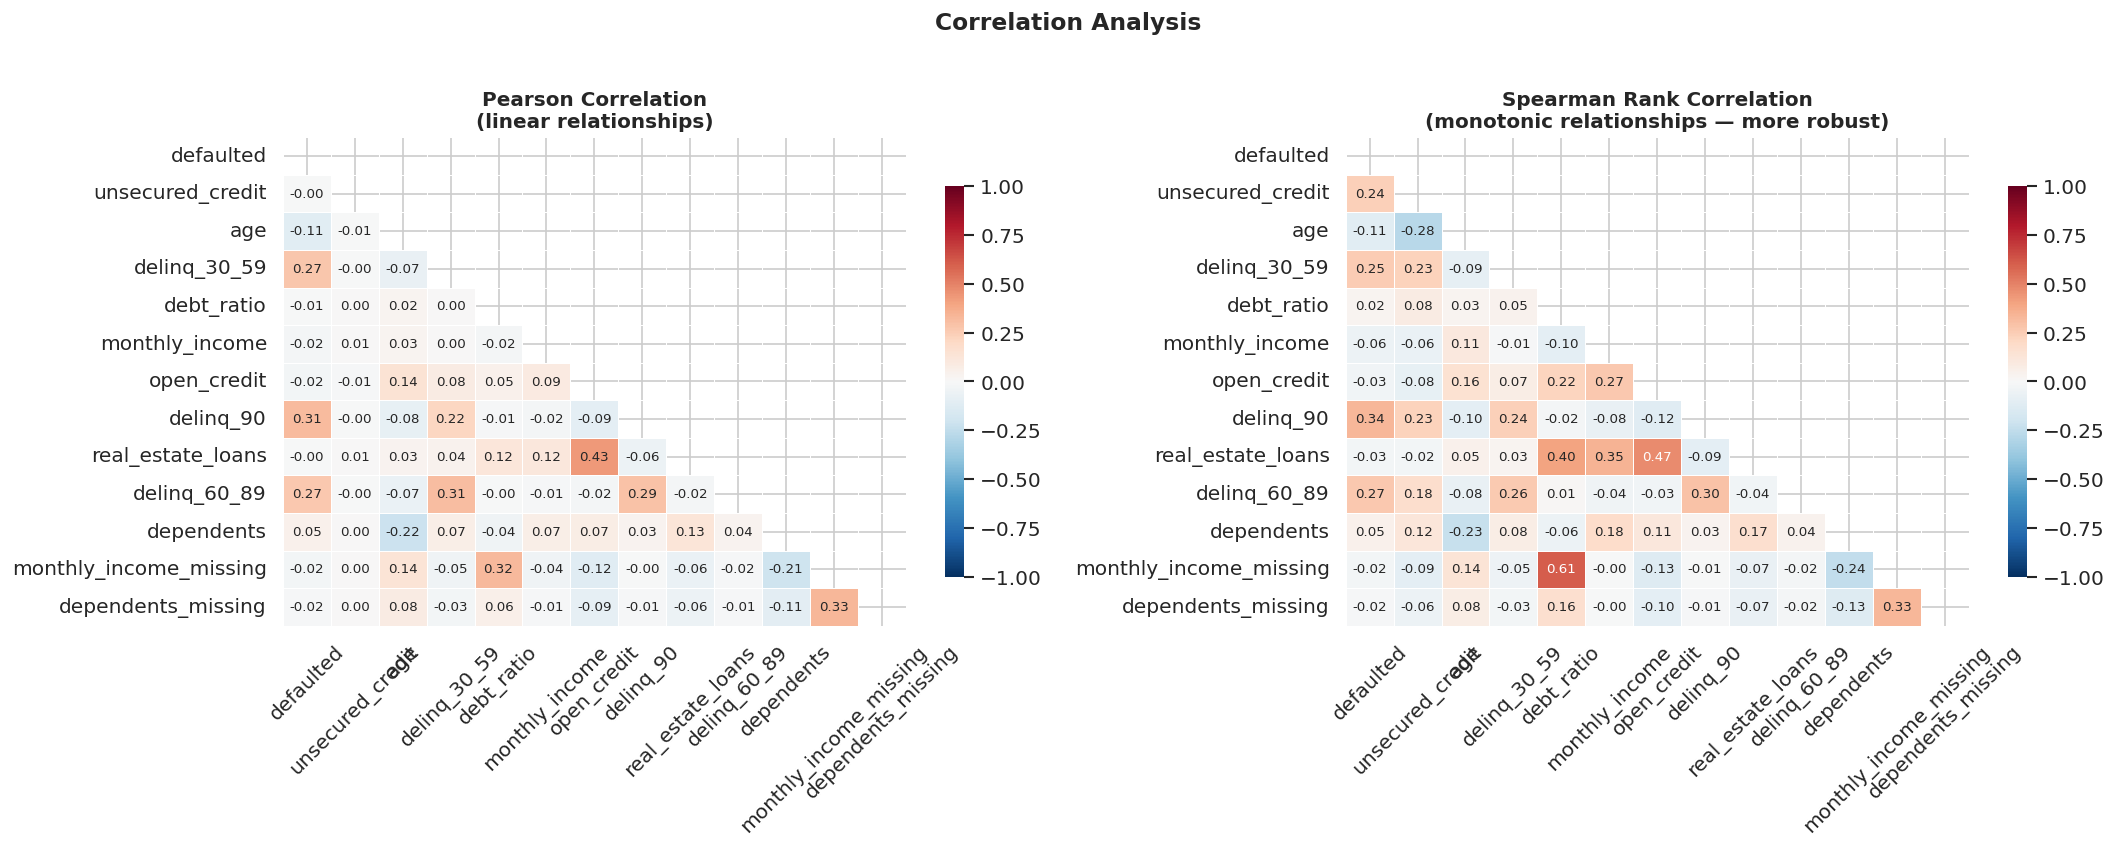

In [63]:
# ── Pearson and Spearman heatmaps side by side ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method, title in zip(axes,
                              ['pearson', 'spearman'],
                              ['Pearson Correlation\n(linear relationships)',
                               'Spearman Rank Correlation\n(monotonic relationships — more robust)']):
    corr = df.corr(method=method, numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                cmap='RdBu_r', vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Correlation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

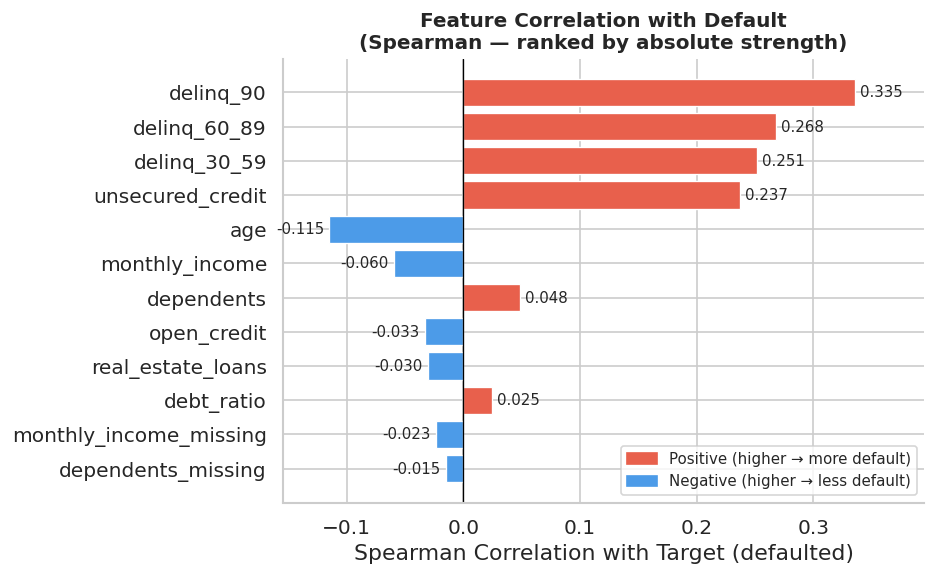

In [64]:
# ── correlation with target — ranked bar chart ────────────────────────────────
target_corr = df.corr(method='spearman', numeric_only=True)['defaulted'] \
                .drop('defaulted') \
                .sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [BAD_CLR if v > 0 else GOOD_CLR for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman Correlation with Target (defaulted)')
ax.set_title('Feature Correlation with Default\n(Spearman — ranked by absolute strength)', fontsize=12, fontweight='bold')
ax.set_xlim(target_corr.min() - 0.04, target_corr.max() + 0.06)

# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BAD_CLR, label='Positive (higher → more default)'),
                   Patch(color=GOOD_CLR, label='Negative (higher → less default)')],
          fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

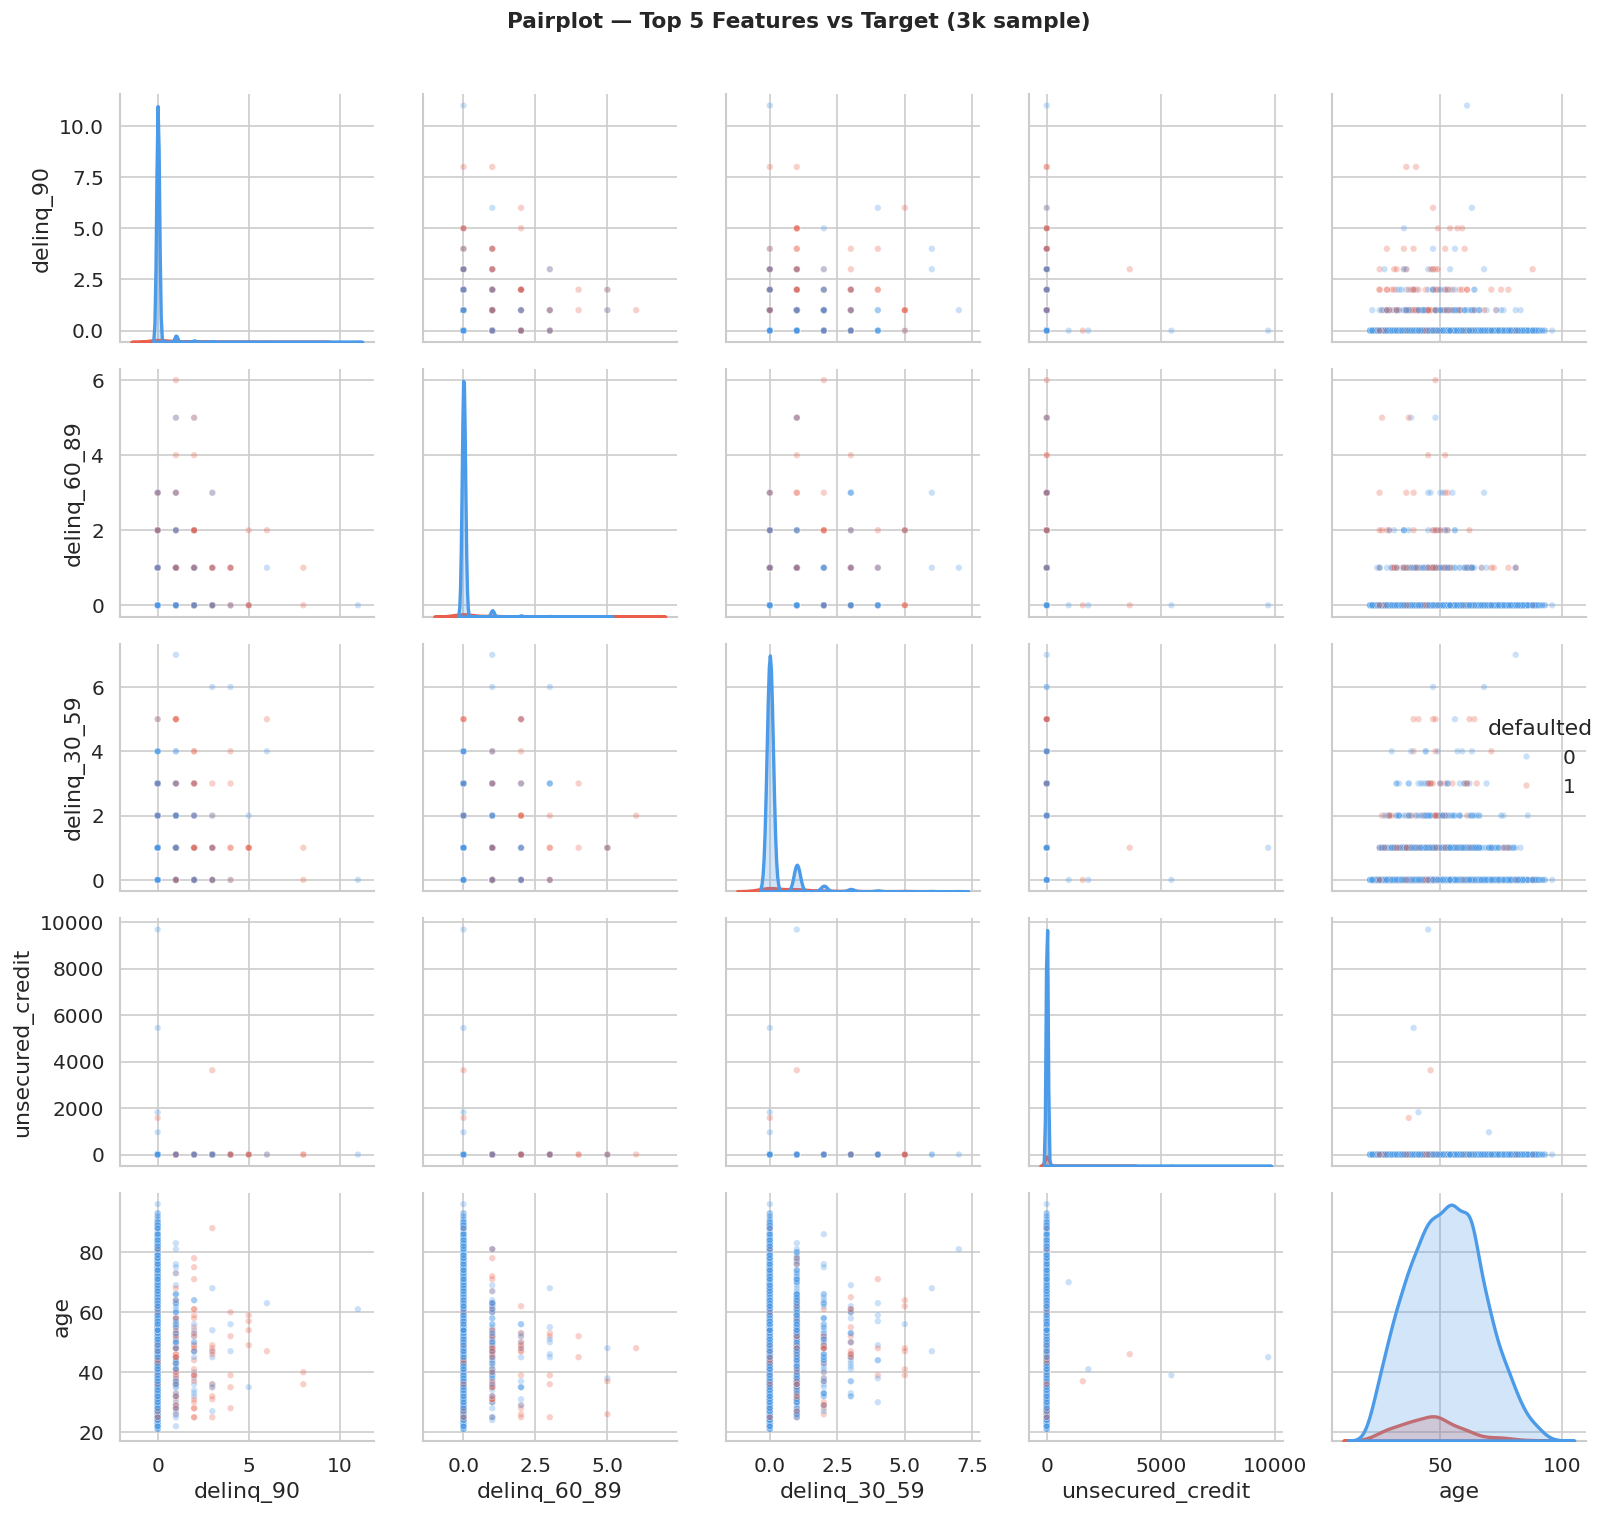

In [65]:
# ── pairplot of top correlated features ──────────────────────────────────────
top_feats = target_corr.abs().nlargest(5).index.tolist() + ['defaulted']

# sample for speed
sample_df = df[top_feats].sample(3000, random_state=SEED)

g = sns.pairplot(sample_df, hue='defaulted',
                 palette=TARGET_PALETTE,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 15},
                 diag_kws={'linewidth': 2})
g.figure.suptitle('Pairplot — Top 5 Features vs Target (3k sample)', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Variance Inflation Factor (VIF) Analysis

**VIF** measures how much a feature's variance is inflated by its linear correlation
with the other features. Rule of thumb: VIF > 5 signals meaningful multicollinearity;
VIF > 10 is severe.

This matters for **logistic regression** (unstable coefficients, wide CIs) but is less
critical for tree-based models (XGBoost, CatBoost) and neural networks.

          Feature      VIF
      open_credit 1.279235
real_estate_loans 1.272499
     delinq_60_89 1.175883
     delinq_30_59 1.143826
        delinq_90 1.132921
              age 1.089237
       dependents 1.082589
   monthly_income 1.020013
       debt_ratio 1.019332
 unsecured_credit 1.000366


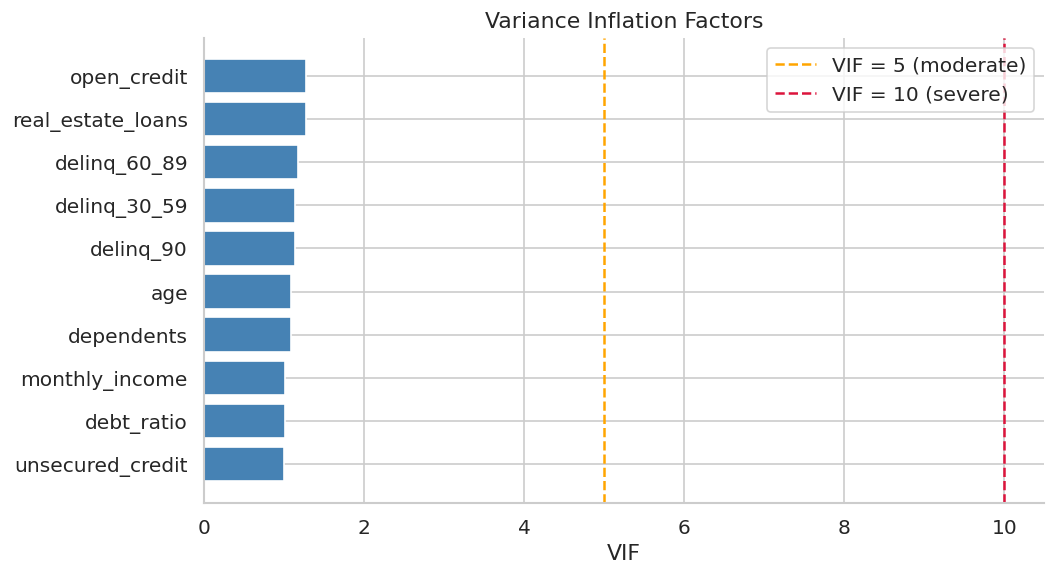

In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

VIF_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents',
]

X_vif = add_constant(df[VIF_COLS].dropna())
vif_df = pd.DataFrame({
    'Feature': VIF_COLS,
    'VIF':     [variance_inflation_factor(X_vif.values, i + 1)
                for i in range(len(VIF_COLS))],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1])
ax.axvline(5,  color='orange', lw=1.5, ls='--', label='VIF = 5 (moderate)')
ax.axvline(10, color='crimson', lw=1.5, ls='--', label='VIF = 10 (severe)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factors')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9 · Mutual Information

### Theory

**Mutual Information (MI)** measures the statistical **dependency** between two variables — both linear *and* non-linear.  
It is grounded in information theory:

$$I(X; Y) = \sum_{x} \sum_{y} p(x, y) \log \frac{p(x, y)}{p(x)\, p(y)}$$

- $I(X;Y) = 0$ means $X$ and $Y$ are **statistically independent** — knowing $X$ tells you nothing about $Y$.
- Higher values indicate **stronger dependency** (unitless, in nats or bits).

**Why use MI alongside correlation?**  
Pearson/Spearman correlation captures only *monotonic* relationships. MI detects *any* dependency — e.g. a U-shaped relationship between age and default would score zero Pearson but positive MI.

**Practical note:** `sklearn`'s `mutual_info_classif` uses a $k$-nearest-neighbour estimator for continuous variables, which handles mixed discrete/continuous features well.

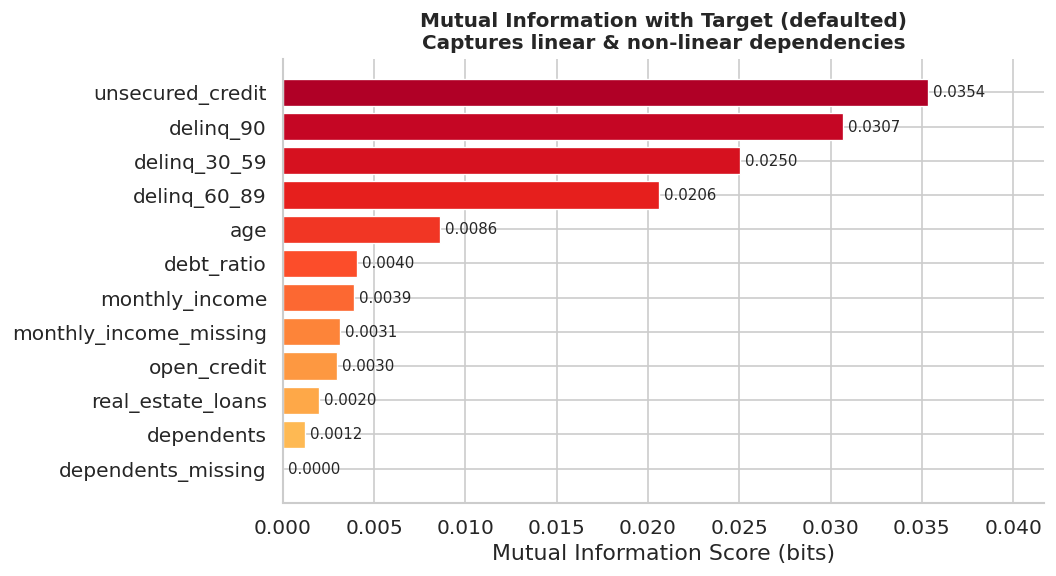

In [67]:
X = df.drop(columns='defaulted')
y = df['defaulted']

# discrete_features flags for count variables
discrete_mask = [col in discrete for col in X.columns]

mi_scores = mutual_info_classif(X, y,
                                 discrete_features=discrete_mask,
                                 random_state=SEED)

mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(mi_df)))
bars = ax.barh(mi_df.index, mi_df.values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Mutual Information Score (bits)')
ax.set_title('Mutual Information with Target (defaulted)\nCaptures linear & non-linear dependencies', fontsize=12, fontweight='bold')
ax.set_xlim(0, mi_df.max() * 1.18)
plt.tight_layout()
plt.show()

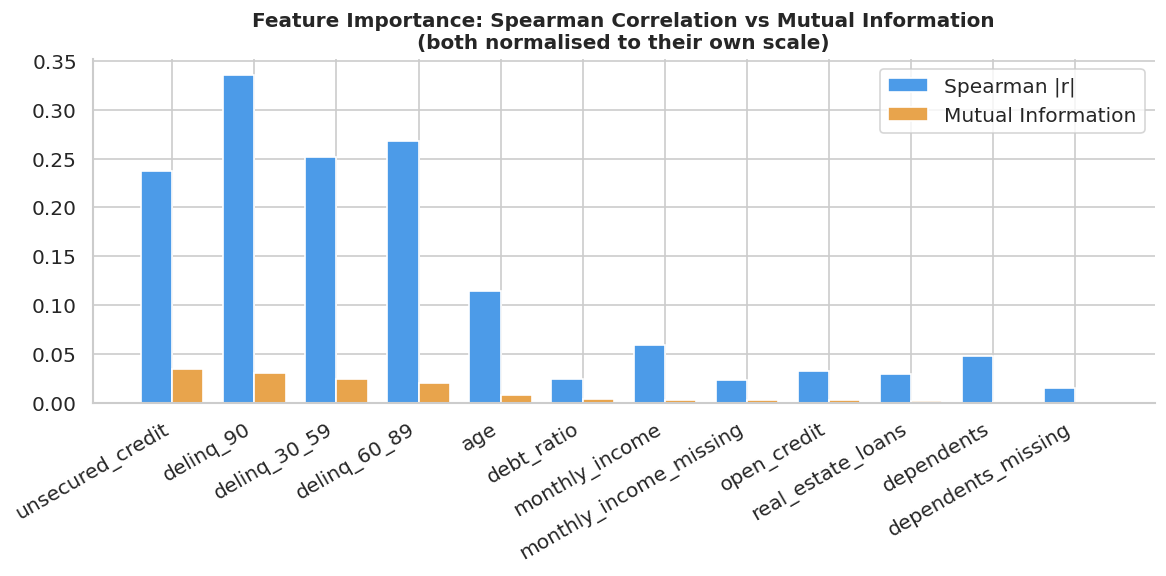

Ranking agreement (Spearman vs MI):
                        Spearman |r| with Target  Mutual Information
unsecured_credit                        0.237084            0.035353
delinq_90                               0.335361            0.030699
delinq_30_59                            0.251447            0.025036
delinq_60_89                            0.268265            0.020595
age                                     0.114835            0.008596
debt_ratio                              0.024945            0.004050
monthly_income                          0.059675            0.003900
monthly_income_missing                  0.023481            0.003145
open_credit                             0.032972            0.002952
real_estate_loans                       0.030382            0.001984
dependents                              0.048472            0.001191
dependents_missing                      0.015191            0.000000


In [68]:
# ── MI vs Spearman correlation — side by side comparison ─────────────────────
spearman_abs = target_corr.abs().reindex(X.columns)

comparison = pd.DataFrame({
    'Spearman |r| with Target': spearman_abs,
    'Mutual Information':        mi_df,
}).sort_values('Mutual Information', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.38
ax.bar(x - w/2, comparison['Spearman |r| with Target'], w,
       label='Spearman |r|', color='#4C9BE8', edgecolor='white')
ax.bar(x + w/2, comparison['Mutual Information'], w,
       label='Mutual Information', color='#E8A44C', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_title('Feature Importance: Spearman Correlation vs Mutual Information\n(both normalised to their own scale)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Ranking agreement (Spearman vs MI):')
print(comparison[['Spearman |r| with Target', 'Mutual Information']].to_string())

---
## 10 · Key Findings Summary

| # | Finding | Implication for Modelling |
|---|---|---|
| 1 | **Class imbalance ~13.5:1** (non-default : default) | Use SMOTE / class weights / threshold tuning; accuracy alone is misleading |
| 2 | **`monthly_income` ~19.8% missing**, MAR/MNAR | Median imputation adequate for baseline; multiple imputation preferred in production |
| 3 | **`dependents` 2.6% missing** — low MI | Zero imputation is defensible; feature may be dropped without significant loss |
| 4 | **Delinquency features** (`delinq_90`, `delinq_30_59`, `delinq_60_89`) are the **strongest predictors** by both Spearman and MI | Include all three; check for multicollinearity — they are mutually correlated |
| 5 | **`unsecured_credit`** has moderate positive correlation with default | High credit card utilisation signals financial stress |
| 6 | **`age`** is negatively correlated with default | Older borrowers default less; non-linear relationship warrants a log or spline transform |
| 7 | **`debt_ratio`** and **`open_credit`** / **`real_estate_loans`** are positively correlated — multicollinearity risk | Consider VIF analysis before logistic regression; regularisation (L2) helps |
| 8 | Income distribution is **heavily right-skewed** | Log-transform `monthly_income` before feeding into linear models |

### Recommended Next Steps
- Log-transform `monthly_income` and `unsecured_credit`
- Address class imbalance with SMOTE or class-weighted loss
- Build a baseline logistic regression using the top 5 MI features
- Compare with a gradient boosted tree (XGBoost / LightGBM) which natively handles imbalance and non-linearities
- Evaluate with AUC-ROC, AUC-PR, and Brier score — not accuracy

---
## 11 · Baseline Logistic Regression

A simple logistic regression serves as a **glass-box baseline** — interpretable
coefficients tell us the direction and magnitude of each feature's effect on the
log-odds of default, and the model's AUC anchors what a linear decision boundary achieves.

> **Note**: `monthly_income` is log1p-transformed here (as recommended by the skewness
> analysis above) and features are standardised before fitting so coefficients are
> directly comparable.

Intercept : -3.0248

          Feature  Coefficient  Odds Ratio
              age      -0.4173      0.6588
        delinq_90       0.4143      1.5134
     delinq_30_59       0.4008      1.4931
     delinq_60_89       0.2512      1.2856
real_estate_loans       0.0782      1.0813
       dependents       0.0496      1.0508
       debt_ratio      -0.0409      0.9599
   monthly_income      -0.0255      0.9748
      open_credit      -0.0234      0.9769
 unsecured_credit      -0.0010      0.9990

────────────────────────────────────────
  ROC-AUC          : 0.8071
  Avg Precision    : 0.3446
  McFadden R²      : 0.1832
  Log-Loss (model) : 0.1986
────────────────────────────────────────

              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27970
     Default       0.62      0.15      0.24      1976

    accuracy                           0.94     29946
   macro avg       0.78      0.57      0.60     29946
weighted avg       0.92      0.94     

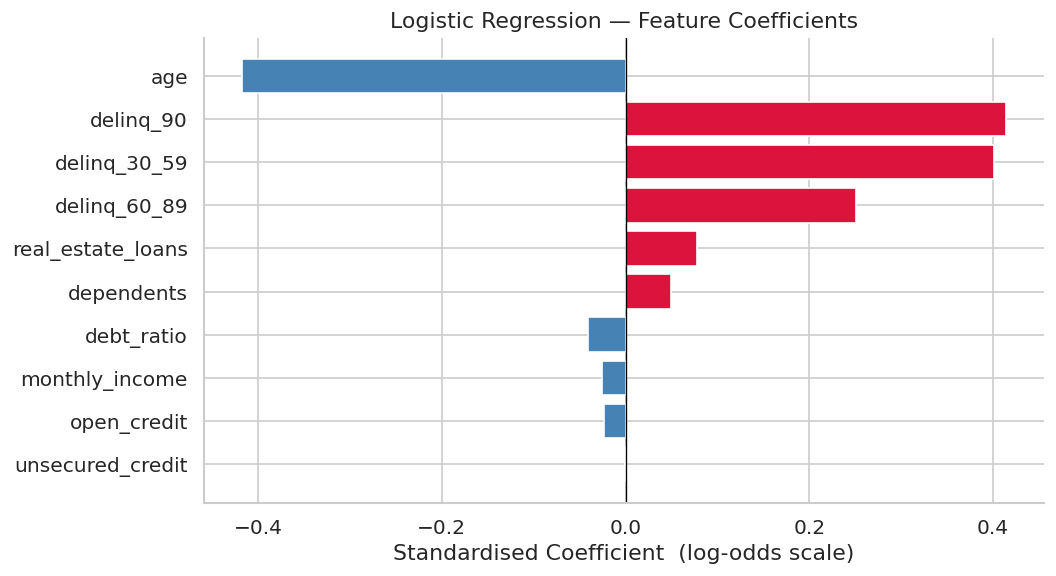

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, log_loss)

# ── Feature matrix (log1p income, then scale) ─────────────────────────────────
LR_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents',
]

df_lr = df[LR_COLS + ['defaulted']].copy()
df_lr['monthly_income'] = np.log1p(df_lr['monthly_income'])

X_lr = df_lr[LR_COLS].values
y_lr = df_lr['defaulted'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_lr, y_lr, test_size=0.20, random_state=42, stratify=y_lr)

scaler_lr = StandardScaler()
X_tr_s    = scaler_lr.fit_transform(X_tr)
X_te_s    = scaler_lr.transform(X_te)

# ── Fit ───────────────────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_tr_s, y_tr)

# ── Coefficients table ────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     LR_COLS,
    'Coefficient': lr.coef_[0],
    'Odds Ratio':  np.exp(lr.coef_[0]),
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print("Intercept :", round(lr.intercept_[0], 4))
print()
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

# ── Goodness of fit ───────────────────────────────────────────────────────────
probs = lr.predict_proba(X_te_s)[:, 1]
preds = lr.predict(X_te_s)

# McFadden pseudo-R²  =  1 - (log-likelihood_model / log-likelihood_null)
null_prob  = y_tr.mean()
ll_null    = -log_loss(y_te, np.full_like(probs, null_prob)) * len(y_te)
ll_model   = -log_loss(y_te, probs) * len(y_te)
pseudo_r2  = 1 - ll_model / ll_null

print(f"\n{'─'*40}")
print(f"  ROC-AUC          : {roc_auc_score(y_te, probs):.4f}")
print(f"  Avg Precision    : {average_precision_score(y_te, probs):.4f}")
print(f"  McFadden R²      : {pseudo_r2:.4f}")
print(f"  Log-Loss (model) : {log_loss(y_te, probs):.4f}")
print(f"{'─'*40}")
print()
print(classification_report(y_te, preds, target_names=['No Default', 'Default']))

# ── Coefficient bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient  (log-odds scale)')
ax.set_title('Logistic Regression — Feature Coefficients')
plt.tight_layout()
plt.show()